# Exploratory Data Analysis

This notebook covers the exploratory data analysis (EDA) for the Bank Marketing dataset. 

It focuses on understanding the data structure, checking data quality, and exploring both numerical and categorical features. 

The goal is to identify key patterns and issues in the data and use these insights to guide preprocessing and modeling decisions.

## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ydata_profiling import ProfileReport
%matplotlib inline

In [2]:
# Load data using project root path

PROJECT_ROOT = Path().resolve().parent.parent
data_path = PROJECT_ROOT / "bank-deposit-prediction" / "data" / "raw" / "bank2.csv"

df = pd.read_csv(data_path, sep=";")

# Preview
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Dataset Overview

In [3]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names, Data types and non-null counts
df.info()

Shape of dataset: (4521, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [4]:
bank_profile = ProfileReport(df, title="Bank Data Profile", explorative=True)
bank_profile.to_file("Bank_profile_report2.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 371370.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Missing Values 

In [5]:
missing_values = df.isnull().sum()

print("Missing values per column:\n")
print(missing_values[missing_values > 0])

Missing values per column:

Series([], dtype: int64)


In [6]:
# Checking 'unknown' values in categorical features

categorical_cols = df.select_dtypes(include='object').columns

print("Columns with 'unknown' values:")

for col in categorical_cols:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        percentage = (count / len(df)) * 100
        print(f"{col}: {count} ({percentage:.2f}%)")

Columns with 'unknown' values:
job: 38 (0.84%)
education: 187 (4.14%)
contact: 1324 (29.29%)
poutcome: 3705 (81.95%)


## Duplicate Records

In [7]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## Outlier Analysis

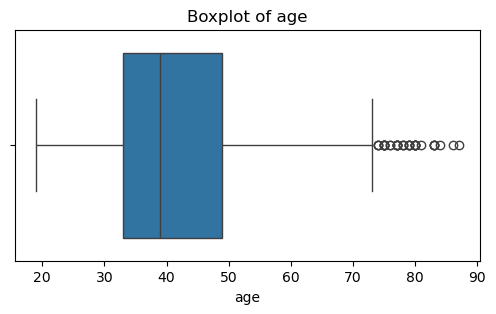

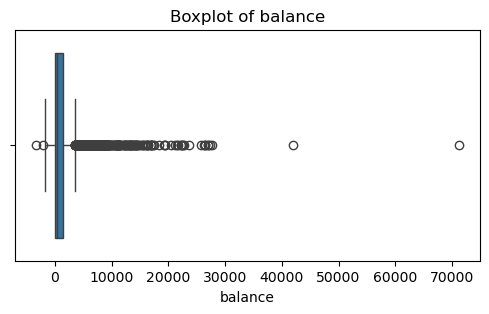

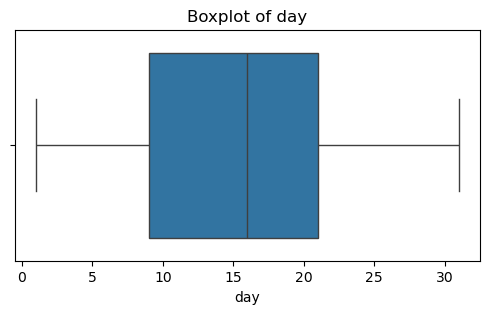

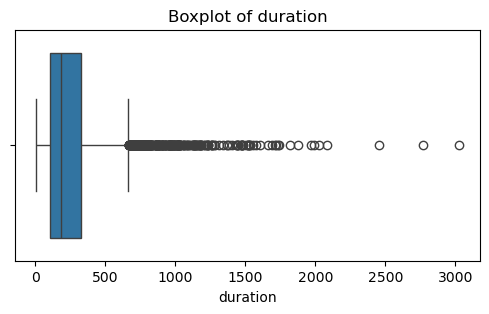

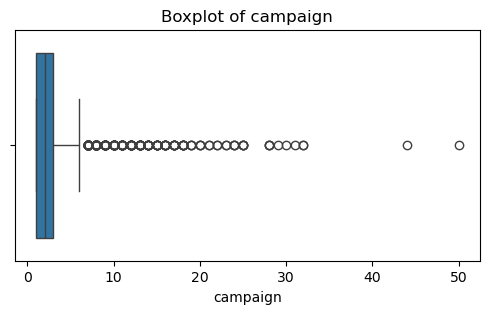

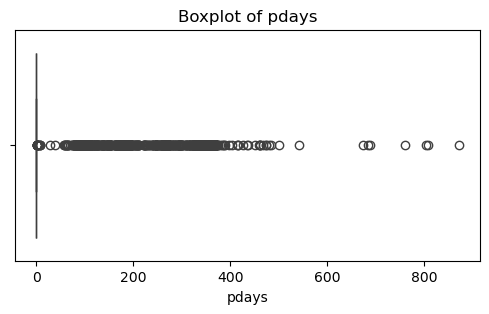

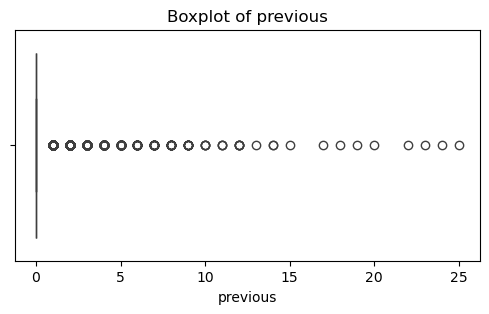

In [8]:
# Visualize numerical distributions to identify outliers
numerical_cols = df.select_dtypes(include=['int64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Target Variable Analysis

y
no     4000
yes     521
Name: count, dtype: int64

Percentage:
 y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64


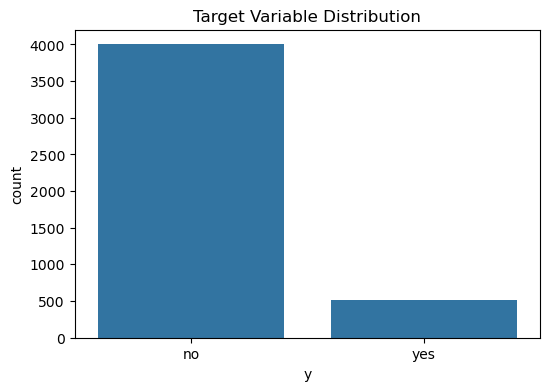

In [9]:
# Count
target_counts = df['y'].value_counts()
print(target_counts)

# Percentage
target_ratio = df['y'].value_counts(normalize=True)
print("\nPercentage:\n", target_ratio)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

## Numerical Features Analysis

In [10]:
# Identify numerical features and generate summary statistics
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:\n", numerical_cols)

# Summary statistics
df[numerical_cols].describe()

Numerical Columns:
 Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


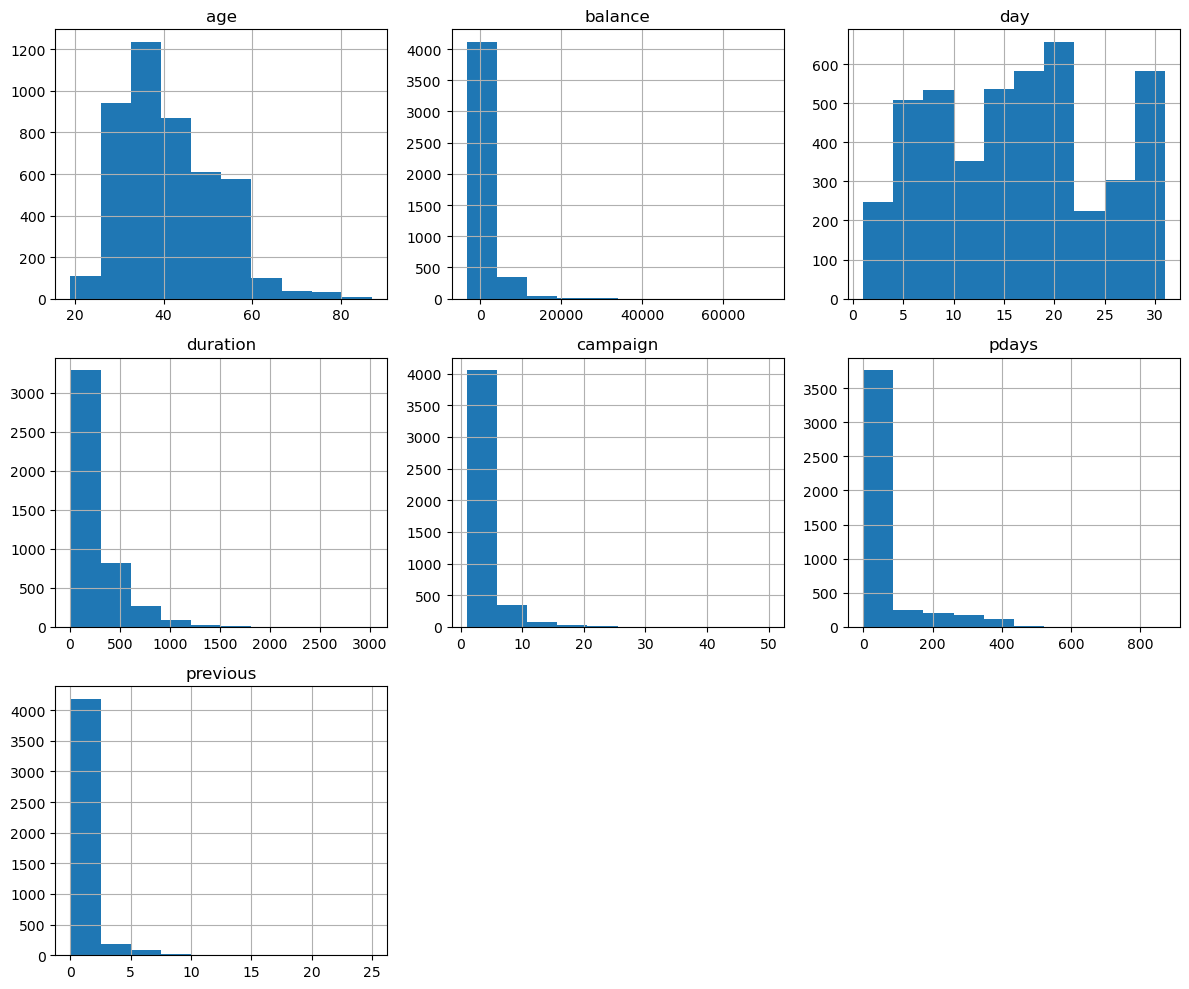

In [11]:
# Plot distributions of numerical features
df[numerical_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

## Categorical Features Analysis

In [12]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols = categorical_cols.drop('y')  # exclude target

print("Categorical Columns:\n", categorical_cols)

Categorical Columns:
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


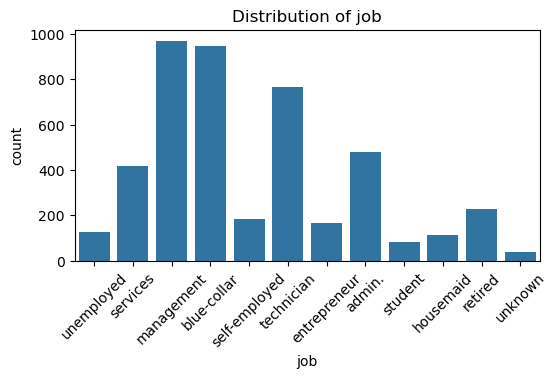

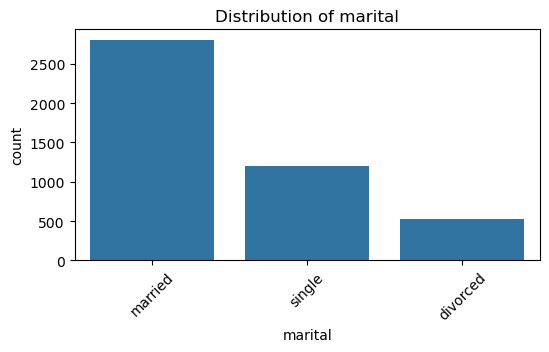

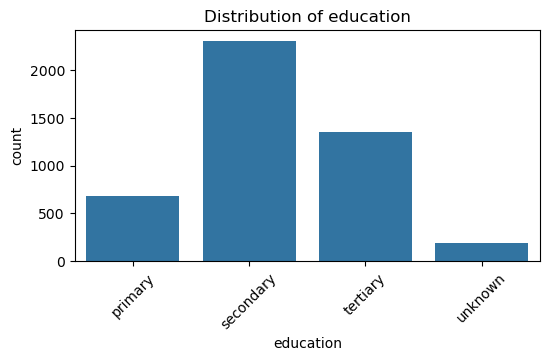

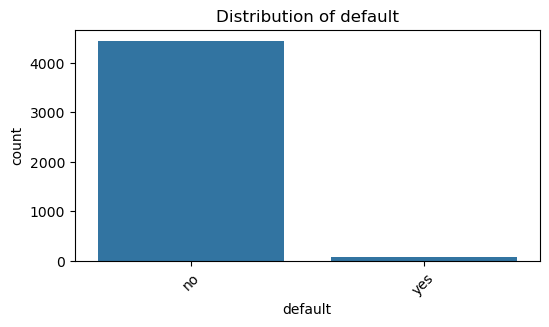

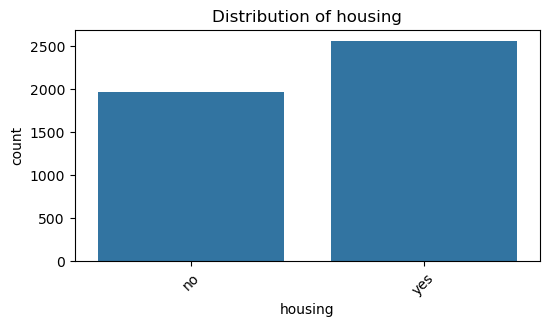

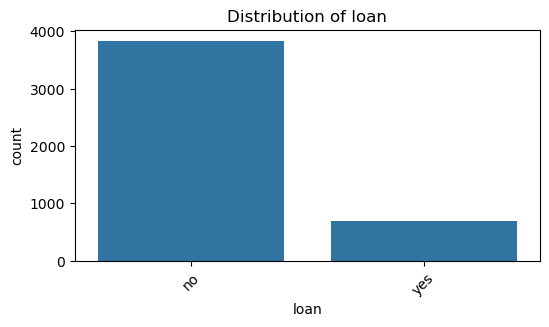

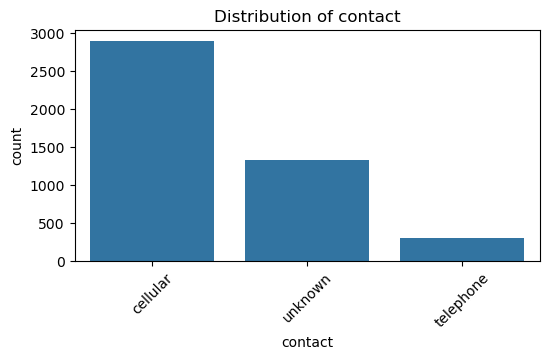

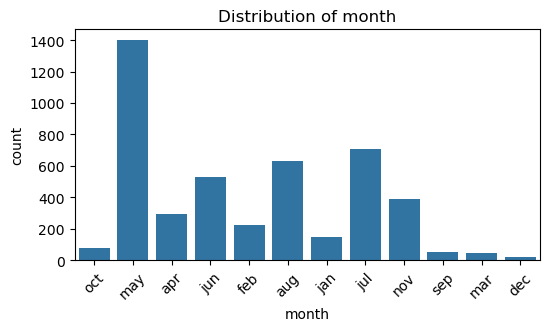

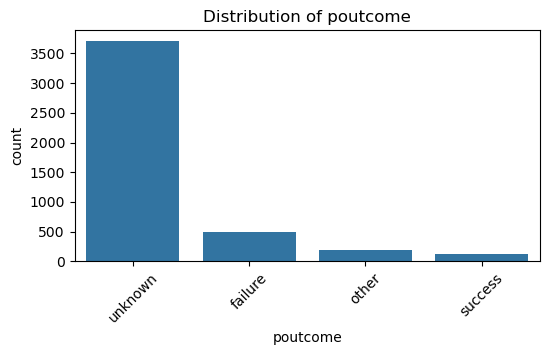

In [13]:
# Visualize distribution of categorical features
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

## Findings & Preprocessing Strategy 

### Findings:

- The dataset contains **4,521 observations** and **17 features**, including:
  - **7 numerical variables**
  - **10 categorical variables** (including binary features)
    


- No explicit missing values were detected. However, several categorical variables contain `"unknown"` values, which act as **implicit missing data**.  
  The feature `poutcome` contains **81.95% "unknown" values**, but it still provides useful information for clients with prior campaign interactions. Therefore, `"unknown"` values are treated as a valid category.



- No duplicate records were found in the dataset.



- The target variable (`y`) is **imbalanced**, with:
  - **88.48% “no”**
  - **11.52% “yes”**



- Outlier analysis revealed that several numerical features, including `balance`, `campaign`, `pdays`, and `previous`, contain extreme values and exhibit skewed distributions.  
  Instead of removing these outliers, they are retained to preserve important information. To reduce their impact on model performance—especially for models sensitive to feature scale(Linear models (LogReg, SVM))—**Robust Scaling** is applied during preprocessing.



- The feature `duration` represents the length of the current phone call and is recorded after the interaction, making it unavailable at prediction time and leading to **data leakage**.  
  Therefore, `duration` is removed prior to modeling.



- Historical features such as `pdays`, `previous`, and `poutcome` provide valuable information about past customer interactions and are available before prediction, making them important predictors.



- The feature `campaign` represents the number of contacts made during the current campaign. It does not directly reveal the outcome and provides useful insight into customer engagement, and is therefore retained.



- The feature `default` is highly imbalanced (almost all values are “no”), indicating **low variance**. It is removed as it is unlikely to contribute meaningful predictive power.


- Although the feature `day` is numerical, it represents a **categorical/time-based concept** (day of the month) rather than a continuous variable. Therefore, it is treated as a categorical feature and encoded accordingly. While this increases dimensionality, the dataset size is manageable and the impact is minimal.



### Preprocessing:
Based on the exploratory data analysis, the following preprocessing steps will be applied:

- Remove leakage and low-variance features:
The features duration (data leakage) and default (low variance) are removed prior to modeling.
- Handle categorical variables:
All categorical features, including day (treated as a categorical/time-based feature), are encoded using one-hot encoding.
- Scale numerical features:
Numerical variables are scaled using RobustScaler to address skewness, reduce outlier impact and improve performance for models sensitive to feature scale.
- Transform pdays feature:
Since pdays = -1 represents “no previous contact” rather than a true numeric value, the feature is transformed by:
    - Creating a binary indicator (previous_contact)
    - Replacing -1 with 0 in the original feature

These steps are implemented within a pipeline to ensure proper handling during cross-validation and to prevent data leakage.